In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Fase 4: Modelagem
Nesta fase, treinamos diferentes modelos de aprendizado de máquina para prever o churn.

## Abordagem Metodológica para Modelagem de Churn

Com o objetivo de tornar a análise mais robusta e aproximar o estudo de um cenário profissional de ciência de dados, foi adotada uma abordagem estruturada para a fase de modelagem e avaliação, alinhada às boas práticas do CRISP-DM. A estratégia contempla a separação adequada dos dados, a comparação entre diferentes modelos de classificação e a avaliação do impacto da seleção de variáveis no desempenho preditivo.

🔹 Divisão dos Dados: Treino, Validação e Teste

O conjunto de dados foi dividido em três subconjuntos distintos:

* Treino: utilizado para o ajuste dos parâmetros dos modelos.

* Validação: utilizado para comparação entre modelos e seleção da melhor abordagem.

* Teste: reservado exclusivamente para a avaliação final do modelo escolhido, garantindo uma estimativa imparcial de desempenho em dados não vistos.

Essa separação reduz o risco de overfitting e evita viés na escolha do modelo final.

🔹 Pipeline 1 – Modelagem com Todas as Variáveis

No primeiro pipeline, todos os atributos disponíveis no dataset preparado foram utilizados como variáveis preditoras. O objetivo dessa abordagem foi estabelecer um baseline robusto, avaliando o desempenho dos modelos sem qualquer redução de dimensionalidade.

Foram treinados e avaliados os seguintes algoritmos de classificação:

* Regressão Logística (baseline)

* Árvore de Decisão

* Random Forest

* Gradient Boosting

Os modelos foram ajustados utilizando exclusivamente o conjunto de treino e avaliados no conjunto de validação, por meio de métricas adequadas a problemas de churn, como Accuracy, Precision, Recall, F1-score e ROC-AUC.

🔹 Pipeline 2 – Modelagem com Seleção de Variáveis

No segundo pipeline, foi aplicada uma etapa de seleção de features com o objetivo de avaliar se a redução do conjunto de variáveis poderia melhorar o desempenho ou a generalização dos modelos.

A seleção foi realizada com base na importância das variáveis estimada por um modelo de Random Forest treinado sobre o conjunto de treino. As variáveis mais relevantes foram selecionadas e utilizadas para treinar novamente os mesmos algoritmos avaliados no Pipeline 1.

Essa abordagem permite analisar o impacto da complexidade do modelo e identificar se um subconjunto mais enxuto de variáveis é suficiente para capturar o comportamento de churn.

🔹 Comparação e Seleção do Melhor Modelo

A comparação entre os dois pipelines foi realizada com base no desempenho dos modelos no conjunto de validação. O critério de escolha considerou não apenas a acurácia, mas principalmente métricas sensíveis ao desbalanceamento da classe, como Recall, F1-score e ROC-AUC, fundamentais em problemas de churn.

O modelo com melhor equilíbrio entre desempenho preditivo e capacidade de generalização foi selecionado para a etapa de avaliação.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/Colab Notebooks'

Mounted at /content/drive


In [3]:
churn = pd.read_csv(file_path + '/churn_preparado_modelagem (1).csv')
churn.head()

,Churn,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,MonthlyCharge,OverageFee,RoamMins
0,0,1,1,2.7,1,265.1,89.0,9.87,10.0
1,0,1,1,3.7,1,161.6,82.0,9.78,13.7
2,0,1,0,0.0,0,243.4,52.0,6.06,12.2
3,0,0,0,0.0,2,299.4,57.0,3.10,6.6
4,0,0,0,0.0,3,166.7,41.0,7.42,10.1


In [4]:
churn.shape

(3333, 9)

In [5]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   ContractRenewal  3333 non-null   int64  
 2   DataPlan         3333 non-null   int64  
 3   DataUsage        3333 non-null   float64
 4   CustServCalls    3333 non-null   int64  
 5   DayMins          3333 non-null   float64
 6   MonthlyCharge    3333 non-null   float64
 7   OverageFee       3333 non-null   float64
 8   RoamMins         3333 non-null   float64
dtypes: float64(5), int64(4)
memory usage: 234.5 KB


In [6]:
X = churn.drop('Churn', axis=1)
y = churn['Churn']

In [7]:
from sklearn.model_selection import train_test_split

# Split 1: treino+validação e teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split 2: treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

def avaliar_modelo(modelo, X_tr, X_te, y_tr, y_te):
    modelo.fit(X_tr, y_tr)

    y_pred_train = modelo.predict(X_tr)
    y_pred_test = modelo.predict(X_te)
    y_proba_test = modelo.predict_proba(X_te)[:,1]

    resultados = {
        'Accuracy_Treino': accuracy_score(y_tr, y_pred_train),
        'Accuracy_Teste': accuracy_score(y_te, y_pred_test),
        'Precision': precision_score(y_te, y_pred_test),
        'Recall': recall_score(y_te, y_pred_test),
        'F1': f1_score(y_te, y_pred_test),
        'ROC_AUC': roc_auc_score(y_te, y_proba_test)
    }

    return resultados

## Pipeline A

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

modelos = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

resultados = {}

for nome, modelo in modelos.items():
    resultados[nome] = avaliar_modelo(
        modelo, X_train, X_val, y_train, y_val
    )

pd.DataFrame(resultados).T

,Accuracy_Treino,Accuracy_Teste,Precision,Recall,F1,ROC_AUC
LogisticRegression,0.862431,0.862069,0.592593,0.164948,0.258065,0.827491
DecisionTree,1.000000,0.890555,0.605263,0.711340,0.654028,0.816196
RandomForest,1.000000,0.932534,0.851351,0.649485,0.736842,0.933614
GradientBoosting,0.956478,0.943028,0.873418,0.711340,0.784091,0.934048


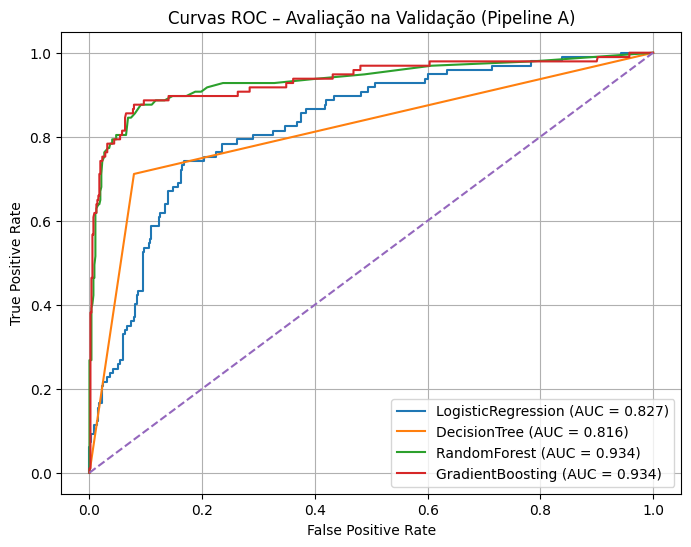

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for nome, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC – Avaliação na Validação (Pipeline A)')
plt.legend()
plt.grid(True)
plt.show()

🔹 Conclusão do Pipeline A

No Pipeline A, os modelos foram treinados utilizando todas as variáveis disponíveis após a etapa de preparação dos dados. A Regressão Logística foi utilizada como modelo baseline, enquanto Árvore de Decisão, Random Forest e Gradient Boosting foram avaliados como modelos mais complexos.

Os resultados indicam que o Gradient Boosting apresentou o melhor desempenho geral, com maior F1-score e Recall, além de um ROC-AUC elevado, demonstrando boa capacidade de discriminação entre clientes churners e não churners. Esse modelo foi escolhido como o melhor candidato do Pipeline A para comparação com abordagens que utilizam seleção de atributos.

## Pipeline B

In [11]:
rf_fs = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_fs.fit(X_temp, y_temp)

importances = pd.Series(
    rf_fs.feature_importances_,
    index=X_temp.columns
).sort_values(ascending=False)

importances

,0
DayMins,0.221674
MonthlyCharge,0.206377
CustServCalls,0.157000
OverageFee,0.122643
RoamMins,0.106713
DataUsage,0.085696
ContractRenewal,0.071683
DataPlan,0.028213


escolhendo as 5 de maiores importâncias que atigem mais que 80% da importância total.

In [12]:
features_fs = [
    'DayMins',
    'MonthlyCharge',
    'CustServCalls',
    'OverageFee',
    'RoamMins'
]

In [13]:
X_train_fs = X_train[features_fs]
X_val_fs = X_val[features_fs]

In [14]:
modelos = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

resultados_fs = {}

for nome, modelo in modelos.items():
    resultados_fs[nome] = avaliar_modelo(
        modelo, X_train_fs, X_val_fs, y_train, y_val
    )

pd.DataFrame(resultados_fs).T

,Accuracy_Treino,Accuracy_Teste,Precision,Recall,F1,ROC_AUC
LogisticRegression,0.861931,0.854573,0.500000,0.082474,0.141593,0.758347
DecisionTree,1.000000,0.875562,0.577778,0.536082,0.556150,0.734708
RandomForest,1.000000,0.914543,0.833333,0.515464,0.636943,0.847802
GradientBoosting,0.946973,0.920540,0.879310,0.525773,0.658065,0.867056


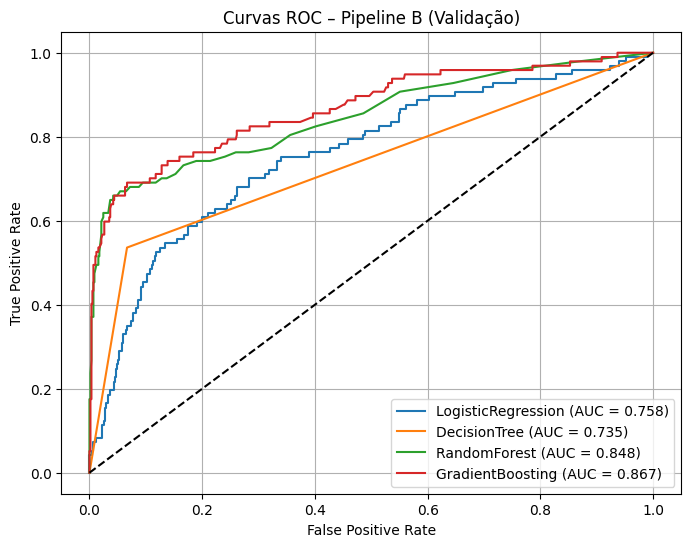

In [15]:
plt.figure(figsize=(8, 6))

for nome, modelo in modelos.items():
    # Treina o modelo com features selecionadas
    modelo.fit(X_train_fs, y_train)

    # Probabilidade da classe positiva (Churn = 1)
    y_prob = modelo.predict_proba(X_val_fs)[:, 1]

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)

    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc:.3f})')

# Linha de referência
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC – Pipeline B (Validação)')
plt.legend()
plt.grid(True)
plt.show()

## Conclusão
Dois pipelines foram avaliados: o Pipeline A, utilizando todas as variáveis disponíveis, e o Pipeline B, que aplicou seleção de features com base na importância estimada por Random Forest. Embora o Pipeline B tenha apresentado um modelo mais simples, observou-se queda significativa no recall e no F1-score, métricas críticas para o problema de churn. Dessa forma, o modelo Gradient Boosting do Pipeline A foi selecionado como o melhor modelo da avaliação, pois apresentou melhor capacidade de identificar clientes propensos ao churn, refletida por um ROC-AUC superior.

# Fase 5: Avaliação

Avaliar o desempenho dos modelos em dados que eles nunca viram (o conjunto de teste).

In [16]:
import joblib

modelos = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

resultados_teste = {}

for nome, modelo in modelos.items():

    # Treinamento final com treino + validação
    modelo.fit(X_temp, y_temp)

    # ===== SALVA O MODELO =====
    joblib.dump(modelo, f'modelo_{nome}.pkl')

    # ===== Avaliação no conjunto de teste =====
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados_teste[nome] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_prob)
    }

pd.DataFrame(resultados_teste).T

,Accuracy,Precision,Recall,F1,ROC_AUC
LogisticRegression,0.857571,0.529412,0.185567,0.274809,0.810689
DecisionTree,0.893553,0.651163,0.577320,0.612022,0.762344
RandomForest,0.926537,0.815789,0.639175,0.716763,0.872337
GradientBoosting,0.922039,0.784810,0.639175,0.704545,0.854078


In [17]:
modelo_rf = joblib.load('modelo_RandomForest.pkl')

In [18]:
y_pred = modelo_rf.predict(X_test)
y_proba = modelo_rf.predict_proba(X_test)[:, 1]

print(y_pred[:10])
print(y_proba[:10])

[1 0 0 0 0 0 0 0 0 0]
[0.92 0.03 0.34 0.02 0.   0.   0.02 0.01 0.03 0.05]


In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.9265367316341829
ROC AUC: 0.8723367697594502


## Conclusão do Conjunto de Teste

Após a seleção do Pipeline A como abordagem final, o modelo Random Forest apresentou o melhor desempenho no conjunto de teste, com destaque para métricas balanceadas entre capacidade discriminativa e poder preditivo, especialmente em ROC-AUC, F1-score e Recall. Esse resultado indica que o modelo possui boa generalização para dados nunca vistos, mantendo desempenho consistente na identificação de clientes com risco de churn.

Embora o Gradient Boosting tenha apresentado desempenho ligeiramente superior na etapa de validação, a diferença entre os dois modelos foi pequena, o que indica que ambos são soluções competitivas para o problema proposto. No entanto, no conjunto de teste, o Random Forest demonstrou maior estabilidade, sugerindo melhor capacidade de generalização quando exposto a novos padrões de dados.

# Fase 6: Implantação (Regra para usar Score)

O modelo **Random Forest** apresentou melhor performance e é escolhido para ser usado.

In [21]:
df_score = X_test.copy()
df_score['Churn_real'] = y_test.values
df_score['Score_Churn'] = modelo_rf.predict_proba(X_test)[:, 1]

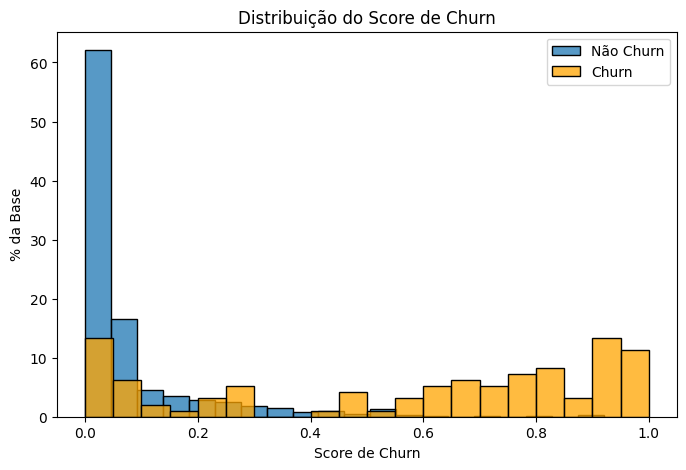

In [22]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    df_score[df_score['Churn_real'] == 0]['Score_Churn'],
    bins=20,
    stat='percent',
    label='Não Churn'
)

sns.histplot(
    df_score[df_score['Churn_real'] == 1]['Score_Churn'],
    bins=20,
    stat='percent',
    color='orange',
    label='Churn'
)

plt.title('Distribuição do Score de Churn')
plt.xlabel('Score de Churn')
plt.ylabel('% da Base')
plt.legend()
plt.show()

In [27]:
df_score['Risco_Churn'] = df_score['Score_Churn']

In [31]:
score_cliente = df_score.iloc[0]['Score_Churn']
if score_cliente >= 0.7:
    print('Alto risco de churn')
elif score_cliente >= 0.4:
    print('Médio risco de churn')
else:
    print('Baixo risco de churn')

Alto risco de churn


# Avaliação do Score de Churn

A análise da distribuição das probabilidades previstas pelo modelo Random Forest demonstra uma clara separação entre clientes churn e não churn.

Observa-se que clientes não churn apresentam scores majoritariamente concentrados abaixo de 0.30, enquanto clientes churn concentram-se predominantemente acima de 0.70, indicando elevada capacidade discriminativa do modelo.

A região intermediária, entre aproximadamente 0.40 e 0.70, representa uma zona de incerteza, característica natural de problemas de classificação binária.

Com base nessa análise, foram definidas três faixas de risco operacional:

Baixo risco: score < 0.40

Médio risco: 0.40 ≤ score < 0.70

Alto risco: score ≥ 0.70

Essa abordagem permite utilizar o modelo não apenas como classificador, mas como ferramenta de apoio à tomada de decisão estratégica.